Juan Jose Vides Garces - 2202040 
Jaider Julian Quintero Rosas - 2225110

In [12]:
import pandas as pd

splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet', 'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"])


splits = {'train': 'yelp_review_full/train-00000-of-00001.parquet', 'test': 'yelp_review_full/test-00000-of-00001.parquet'}
df2 = pd.read_parquet("hf://datasets/Yelp/yelp_review_full/" + splits["train"])

In [13]:
df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [14]:
df2.head()

,label,text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


## Exploración de la distribución de Labels

In [15]:
# Ver la distribución de labels en cada dataset
print("Distribución de labels en IMDB (df):")
print(df['label'].value_counts().sort_index())
print("\nDistribución de labels en Yelp (df2):")
print(df2['label'].value_counts().sort_index())

Distribución de labels en IMDB (df):
label
0    12500
1    12500
Name: count, dtype: int64

Distribución de labels en Yelp (df2):
label
0    130000
1    130000
2    130000
3    130000
4    130000
Name: count, dtype: int64


## Visualizaciones de la distribución de calificaciones (Labels)

KeyError: 'stars'

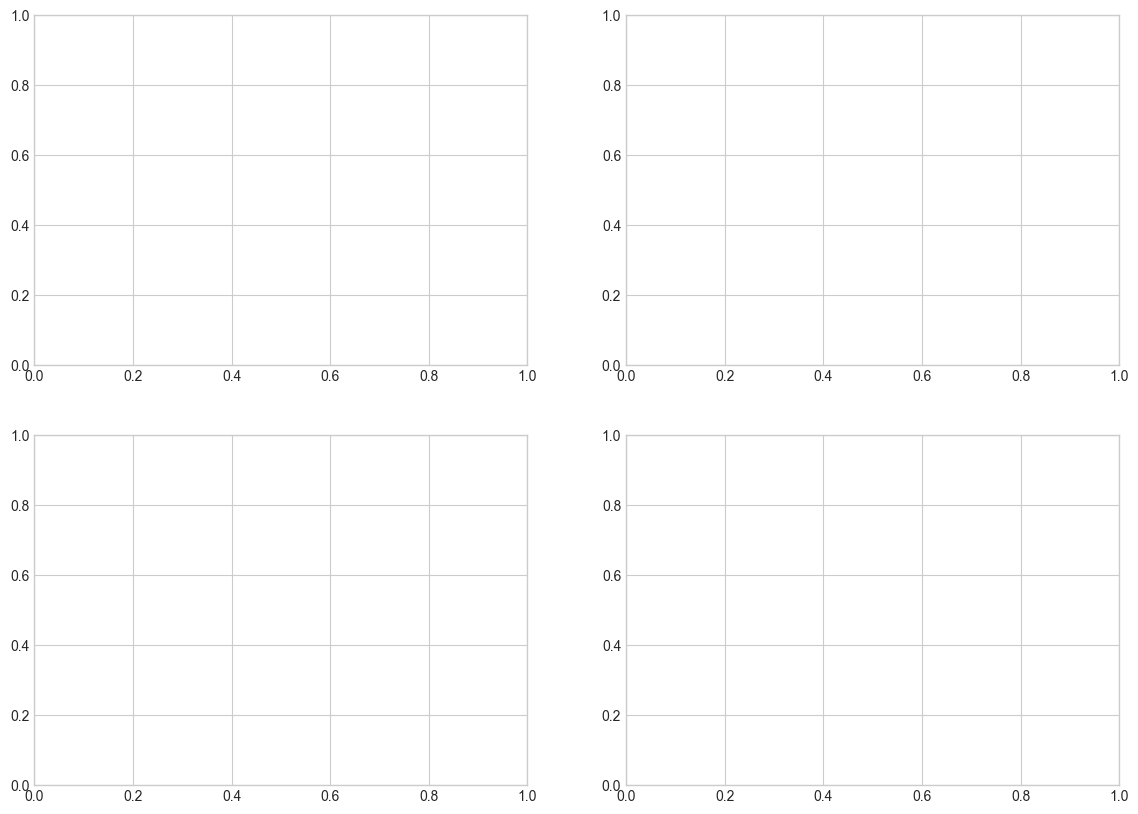

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Crear figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución general de estrellas (dataset unificado)
ax1 = axes[0, 0]
star_counts =df['stars'].value_counts().sort_index()
bars1 = ax1.bar(star_counts.index, star_counts.values, color=sns.color_palette("viridis", 5), edgecolor='black')
ax1.set_xlabel('Estrellas', fontsize=12)
ax1.set_ylabel('Cantidad de reseñas', fontsize=12)
ax1.set_title('Distribución de Calificaciones (Dataset Unificado)', fontsize=14, fontweight='bold')
ax1.set_xticks([1, 2, 3, 4, 5])
for bar, count in zip(bars1, star_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{count:,}', ha='center', va='bottom', fontsize=9)

# 2. Distribución de estrellas por fuente (IMDB vs Yelp)
ax2 = axes[0, 1]
star_by_source =df.groupby(['stars', 'source']).size().unstack(fill_value=0)
star_by_source.plot(kind='bar', ax=ax2, color=['#2ecc71', '#3498db'], edgecolor='black')
ax2.set_xlabel('Estrellas', fontsize=12)
ax2.set_ylabel('Cantidad de reseñas', fontsize=12)
ax2.set_title('Distribución de Calificaciones por Fuente', fontsize=14, fontweight='bold')
ax2.set_xticklabels([1, 2, 3, 4, 5], rotation=0)
ax2.legend(title='Fuente')

# 3. Gráfico de pastel - Proporción de estrellas (Yelp)
ax3 = axes[1, 0]
yelp_stars = df2['label_stars'].value_counts().sort_index()
colors_pie = sns.color_palette("coolwarm", 5)
labels_pie = ['1 estrella', '2 estrellas', '3 estrellas', '4 estrellas', '5 estrellas']
explode = (0.05, 0.02, 0.02, 0.02, 0.05)
ax3.pie(yelp_stars.values, labels=labels_pie, autopct='%1.1f%%', startangle=90, 
        colors=colors_pie, explode=explode, shadow=True)
ax3.set_title('Proporción de Calificaciones (Yelp)', fontsize=14, fontweight='bold')

# 4. Gráfico de barras horizontales - Labels originales (0-4)
ax4 = axes[1, 1]
label_names = {0: '1 estrella (0)', 1: '2 estrellas (1)', 2: '3 estrellas (2)', 
               3: '4 estrellas (3)', 4: '5 estrellas (4)'}
unified_labels =df['label_stars'].value_counts().sort_index()
y_pos = range(len(unified_labels))
colors_h = sns.color_palette("RdYlGn", 5)
bars4 = ax4.barh(y_pos, unified_labels.values, color=colors_h, edgecolor='black')
ax4.set_yticks(y_pos)
ax4.set_yticklabels([label_names[i] for i in unified_labels.index])
ax4.set_xlabel('Cantidad de reseñas', fontsize=12)
ax4.set_title('Labels (0-4) con equivalencia en estrellas', fontsize=14, fontweight='bold')
for bar, count in zip(bars4, unified_labels.values):
    ax4.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('distribucion_calificaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGráfica guardada como 'distribucion_calificaciones.png'")

C:\Users\xxrairexx\AppData\Local\Temp\ipykernel_11828\2587711413.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='label', palette=['#2ecc71', '#3498db'], ax=ax6)


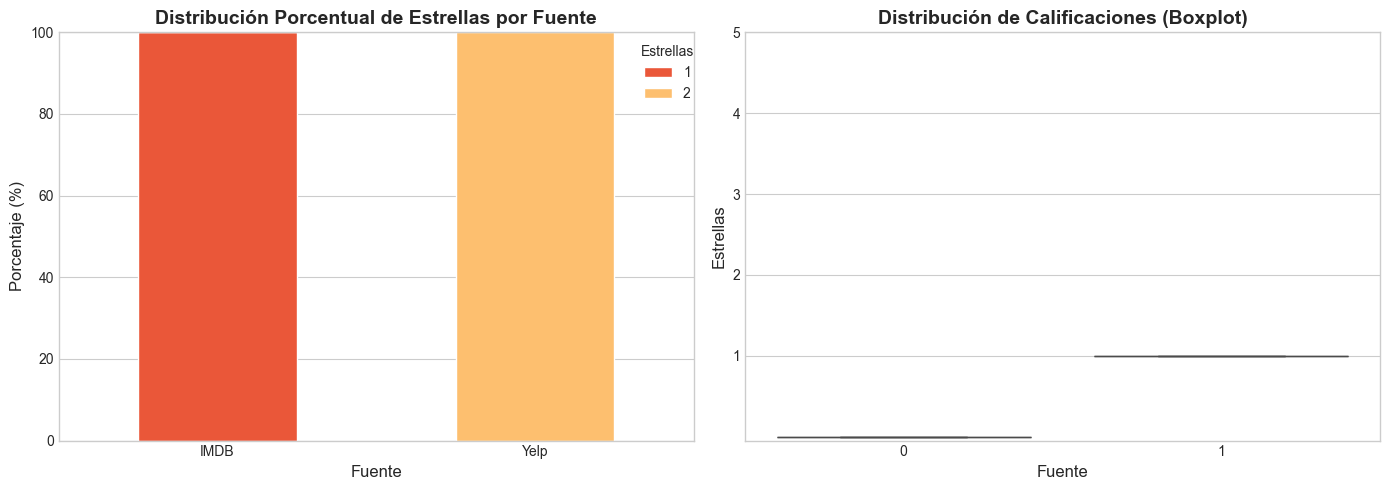


Gráfica guardada como 'comparacion_fuentes.png'


In [24]:
# Visualización adicional: Comparación detallada entre fuentes
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras apiladas normalizado (porcentaje)
ax5 = axes2[0]
star_pct = df.groupby(['label', 'label']).size().unstack(fill_value=0)
star_pct_norm = star_pct.div(star_pct.sum(axis=1), axis=0) * 100
star_pct_norm.plot(kind='bar', stacked=True, ax=ax5, 
                   color=sns.color_palette("RdYlGn", 5), edgecolor='white')
ax5.set_xlabel('Fuente', fontsize=12)
ax5.set_ylabel('Porcentaje (%)', fontsize=12)
ax5.set_title('Distribución Porcentual de Estrellas por Fuente', fontsize=14, fontweight='bold')
ax5.set_xticklabels(['IMDB', 'Yelp'], rotation=0)
ax5.legend(title='Estrellas', labels=['1', '2', '3', '4', '5'], bbox_to_anchor=(1.02, 1))

# Boxplot de calificaciones por fuente
ax6 = axes2[1]
sns.boxplot(data=df, x='label', y='label', palette=['#2ecc71', '#3498db'], ax=ax6)
ax6.set_xlabel('Fuente', fontsize=12)
ax6.set_ylabel('Estrellas', fontsize=12)
ax6.set_title('Distribución de Calificaciones (Boxplot)', fontsize=14, fontweight='bold')
ax6.set_yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('comparacion_fuentes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGráfica guardada como 'comparacion_fuentes.png'")

In [23]:
# Resumen estadístico de las calificaciones
print("=" * 60)
print("RESUMEN ESTADÍSTICO DE CALIFICACIONES")
print("=" * 60)

print("\n  Dataset Unificado:")
print(f"   Total de reseñas: {len(df):,}")
print(f"   Promedio de estrellas: {df['label'].mean():.2f}")
print(f"   Mediana de estrellas: {df['label'].median():.1f}")
print(f"   Desviación estándar: {df['label'].std():.2f}")

print("\n Por fuente:")
for source in ['IMDB', 'Yelp']:
    subset = df[df['label'] == source]
    print(f"\n   {source}:")
    print(f"      - Reseñas: {len(subset):,}")
    print(f"      - Promedio: {subset['label'].mean():.2f} estrellas")
    print(f"      - Mediana: {subset['label'].median():.1f} estrellas")



RESUMEN ESTADÍSTICO DE CALIFICACIONES

  Dataset Unificado:
   Total de reseñas: 25,000
   Promedio de estrellas: 0.50
   Mediana de estrellas: 0.5
   Desviación estándar: 0.50

 Por fuente:

   IMDB:
      - Reseñas: 0
      - Promedio: nan estrellas
      - Mediana: nan estrellas

   Yelp:
      - Reseñas: 0
      - Promedio: nan estrellas
      - Mediana: nan estrellas
